In [65]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In this homework you will analyze gene expression and drug sensitivity data from cancer cell lines. The files’ contents are the following:

1) sample_info.csv: general metadata about the cancer cell lines used. The first column (DepMap_ID) is a unique ID of the cell line. The following columns give information about the cell lines like tissue type etc.

2) CCLE_expression.csv: gene expression data of the used cancer cell line. The first column is the DepMap_ID of the cell line, while the first row contains the gene ids (in X (Y) format, where X is gene symbol; Y is Gene ID). Gene expression is displayed in log2(TPM+1) units.

3) GDSC2_fitted_dose_response_25Feb20.xlsx: drug sensitivity data of the cancer cell lines. Each row contains the drug sensitivity metric (LN_IC50 column, which represents natural logarithm of the half maximal inhibitory concentration) for a given cell line (SANGER_MODEL_ID column) and a given drug (DRUG_NAME column).

Cell lines can be matched with the help of sample_info.csv, which contains not only DepMap_ID, but also Sanger_Model_ID.

The goals are the following:

- Use some dimension reduction / clustering / visualization methods to show the general structure of the cell line data, using gene expression
- Try to identify gene expression-based biomarkers for the drug Lapatinib using statistical methodologies and give a brief biological interpretation of these biomarkers.
- Try to use a predictive model (statistical or machine learning) to predict a cell line’s Lapatinib sensitivity based on its gene expression values. Give an estimate about the predictive performance of this model.
- What other data type could be used to improve the prediction performance of the model? Could you suggest databases to find these type of data?

# Dependencies

In [66]:
# Disclaimer: For some of the code I used Google Gemini

In [67]:
# uncomment to install dependencies

# import sys
# !{sys.executable} -m pip install pandas
# !{sys.executable} -m pip install openpyxl
# !{sys.executable} -m pip install seaborn
# !{sys.executable} -m pip install scikit-learn
# !{sys.executable} -m pip install umap-learn
# !{sys.executable} -m pip install statsmodels
# !{sys.executable} -m pip install gseapy

# Quality and Plausibility check of dataset

I will do some basic checks here to check I if understood the dataset correctly.

In [68]:
path2sample_info = os.path.join("data", "sample_info.csv")
path2expression_data = os.path.join("data", "CCLE_expression.csv")
path2dose_response = os.path.join("data", "GDSC2_fitted_dose_response_25Feb20.xlsx")

In [69]:
df_sample_info = pd.read_csv(path2sample_info)
print(df_sample_info.shape)
df_sample_info.head(n=2)

(1829, 22)


,DepMap_ID,cell_line_name,stripped_cell_line_name,CCLE_Name,alias,COSMICID,sex,source,RRID,WTSI_Master_Cell_ID,...,primary_disease,Subtype,age,Sanger_Model_ID,depmap_public_comments,lineage,lineage_subtype,lineage_sub_subtype,lineage_molecular_subtype,culture_type
0,ACH-000001,NIH:OVCAR-3,NIHOVCAR3,NIHOVCAR3_OVARY,OVCAR3,905933.0,Female,ATCC,CVCL_0465,2201.0,...,Ovarian Cancer,"Adenocarcinoma, high grade serous",60.0,SIDM00105,NaN,ovary,ovary_adenocarcinoma,high_grade_serous,NaN,Adherent
1,ACH-000002,HL-60,HL60,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,905938.0,Female,ATCC,CVCL_0002,55.0,...,Leukemia,"Acute Myelogenous Leukemia (AML), M3 (Promyelo...",35.0,SIDM00829,NaN,blood,AML,M3,NaN,Suspension


In [70]:
# We double check that each row of the sample info has a unique DepMap_ID
l = len( pd.unique(df_sample_info['DepMap_ID']) )
l

1829

In [71]:
# Next we look at the expression data
df_expression_data = pd.read_csv(path2expression_data)
df_expression_data.columns.values[0] = 'DepMap_ID'
print(df_expression_data.shape)
df_expression_data.head()

(1393, 19178)


,DepMap_ID,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),...,ARHGAP11B (89839),AC004593.2 (1124),AC090517.4 (54816),AL160269.1 (11046),ABCF2-H2BE1 (114483834),POLR2J3 (548644),H2BE1 (114483833),AL445238.1 (647264),GET1-SH3BGR (106865373),AC113348.1 (102724657)
0,ACH-001113,4.990501,0.000000,7.273702,2.765535,4.480265,0.028569,1.269033,3.058316,6.483171,...,1.214125,0.000000,0.111031,0.150560,1.427606,5.781884,0.0,0.000000,0.799087,0.000000
1,ACH-001289,5.209843,0.545968,7.070604,2.538538,3.510962,0.000000,0.176323,3.836934,4.200850,...,1.835924,0.000000,0.310340,0.000000,0.807355,4.704319,0.0,0.000000,0.464668,0.070389
2,ACH-001339,3.779260,0.000000,7.346425,2.339137,4.254745,0.056584,1.339137,6.724241,3.671293,...,1.823749,0.084064,0.176323,0.042644,1.384050,4.931683,0.0,0.028569,0.263034,0.000000
3,ACH-001538,5.726831,0.000000,7.086189,2.543496,3.102658,0.000000,5.914565,6.099716,4.475733,...,0.871844,0.137504,0.263034,2.485427,0.713696,3.858976,0.0,0.000000,0.000000,0.000000
4,ACH-000242,7.465648,0.000000,6.435462,2.414136,3.864929,0.831877,7.198003,5.452530,7.112492,...,2.324811,0.163499,0.163499,0.000000,1.117695,4.990501,0.0,0.000000,0.000000,0.000000


A DepMap_ID is a unique, standardized identifier used to catalog human cancer cell lines. The column names correspond to genes. We see that the number roughly matches 20000 which is approximately the number of genes humans have. Furtheromore, we observe that there are many more columns than rows. This is important since it limits statistical power and impacts therefore the choice of models.

We also expect that no DepMap_ID appears 2 times in the dataset (i.e. DepMap_IDs are unique in the dataset). As a quick check we verify that the number of rows (representing cell lines) matches the number of unique DepMap_IDs in the dataset.

In [72]:
l = len( pd.unique(df_expression_data['DepMap_ID']) )
assert df_expression_data.shape[0] == l
l

1393

However, note that the number of unique DepMap_IDs is not the same in the dataset df_sample_info and df_expression_data. The sample info dataframe contains 1829 while the expression data set  contains 1393 unique DepMap_IDs. It seems that there are sample for which no gene expression data is available.

To confirm this we check if the DepMap_IDs in df_expression_data appear all in df_sample_info:

In [73]:
all_present = df_expression_data['DepMap_ID'].isin(df_sample_info['DepMap_ID']).all()
assert all_present

So for all entries in the gene expression dataset we have meta data.

In [74]:
# Now let us load the dataset with the drug sensitivity data of the cancer cell lines
df_response = pd.read_excel(path2dose_response, sheet_name='Sheet 1')
print(df_response.shape)
df_response.head()

(135242, 19)


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,282,13320532,749709,HCC1954,SIDM00872,BRCA,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000098,0.1,-0.251083,0.975203,0.112373,0.906631
1,GDSC2,282,13320565,749710,HCC1143,SIDM00866,BRCA,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000098,0.1,1.343315,0.978464,0.067577,1.683567
2,GDSC2,282,13320598,749711,HCC1187,SIDM00885,BRCA,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000098,0.1,1.736985,0.995100,0.045205,1.875399
3,GDSC2,282,13320631,749712,HCC1395,SIDM00884,BRCA,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000098,0.1,-2.309078,0.867832,0.107282,-0.096212
4,GDSC2,282,13320668,749713,HCC1599,SIDM00877,BRCA,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000098,0.1,-3.106684,0.777532,0.098286,-0.484878


We notice that the drug sensitivity data uses instead of DepMap_IDs another cell line identification system.

While the DepMap_ID (the ACH- prefix) is the primary identifier used by the Broad Institute, the SANGER_MODEL_ID (usually starting with SIDM-) is its counterpart from the Wellcome Sanger Institute.

It is part of the Cancer Dependency Map (Cancer DepMap) effort in the UK, specifically associated with the Cell Model Passports database. Both identifiers refer to the same physical cell lines.

We test if we have the same number of cell lines names and Sanger Model IDs.

In [75]:
l1 = len( pd.unique(df_response['CELL_LINE_NAME']) )
l2 = len( pd.unique(df_response['SANGER_MODEL_ID']) )
assert l1 == l2
l1, l2

(809, 809)

In this notebook we are primarily interested in the drug Lapatinib. In the given dataset different drugs seem to be tested on each cell line. The total number of tested drugs can be found in the next cell.

In [76]:
number_of_drugs_in_dataset = len( pd.unique(df_response['DRUG_NAME']) )
number_of_drugs_in_dataset

192

To understand how the data looks, let us look at the entries of one arbitrary cell line: SIDM00872

In [77]:
sanger_id = 'SIDM00872'
filt = (df_response['SANGER_MODEL_ID'] == sanger_id)
l = len( pd.unique( df_response[filt]['DRUG_NAME'] ) )
k = df_response[filt].shape[0]
print(f"Number of drugs tested for Sanger Model Id {sanger_id}: {l}".format(l, sanger_id))
print(f"Number of entries for Sanger Model Id {sanger_id}: {k}".format(k, sanger_id))
df_response[filt].head(n=3)

Number of drugs tested for Sanger Model Id SIDM00872: 189
Number of entries for Sanger Model Id SIDM00872: 195


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,282,13320532,749709,HCC1954,SIDM00872,BRCA,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.000098,0.1,-0.251083,0.975203,0.112373,0.906631
887,GDSC2,282,13333232,749709,HCC1954,SIDM00872,BRCA,1004,Vinblastine,Microtubule destabiliser,Mitosis,1046,Y,0.000100,0.1,-3.058914,0.823151,0.173193,0.249127
1558,GDSC2,282,13319017,749709,HCC1954,SIDM00872,BRCA,1005,Cisplatin,DNA crosslinker,DNA replication,1046,Y,0.003906,6.0,5.005908,0.991170,0.045147,0.712196


We see that there are from the total 192 drugs only 189 tested on the cell line with Sanger_Model_ID SIDM00872. Also since there are more rows (195) than drugs in the dataset. Some drugs seem to be tested multiple times for the same cell line.

Now let us look at the entries with the drug Lapatinib:

In [78]:
filt_lapatinib = (df_response['DRUG_NAME'] == 'Lapatinib')
df_response_lapatinib = df_response[filt_lapatinib]
l1 = df_response_lapatinib.shape[0]
l2 = len( pd.unique(df_response_lapatinib['SANGER_MODEL_ID']) )
print(f"Number of entries in the dataset for the drug Lapatinib: {l1}".format(l))
print(f"Number of Sanger Model IDs in the dataset for the drug Lapatinib: {l2}".format(l))
df_response_lapatinib.head(n=3)

Number of entries in the dataset for the drug Lapatinib: 757
Number of Sanger Model IDs in the dataset for the drug Lapatinib: 757


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
51103,GDSC2,282,13320559,749709,HCC1954,SIDM00872,BRCA,1558,Lapatinib,"EGFR, ERBB2",EGFR signaling,1046,Y,0.009766,10.0,1.789904,0.845979,0.106827,-0.617389
51104,GDSC2,282,13320592,749710,HCC1143,SIDM00866,BRCA,1558,Lapatinib,"EGFR, ERBB2",EGFR signaling,1046,Y,0.009766,10.0,1.918809,0.815827,0.127784,-0.541896
51105,GDSC2,282,13320625,749711,HCC1187,SIDM00885,BRCA,1558,Lapatinib,"EGFR, ERBB2",EGFR signaling,1046,Y,0.009766,10.0,5.148251,0.986542,0.085755,1.349425


Since both numbers are the same we can identify the entries in the dataset with Sanger Model IDs. For the drug Lapatinib no cell line was multiple times tested.

Since we are going to use the column "LN_IC50" as output variable for two models in the following we should also check its distribution. LN_IC50 represents the natural logarithm of the half maximal inhibitory concentration for a given drug and cell line. The logarithm is taken to make its distribution resemble a normal dsitribution and more easy to handle. Consequently, we would expect something similar to a bell curve.

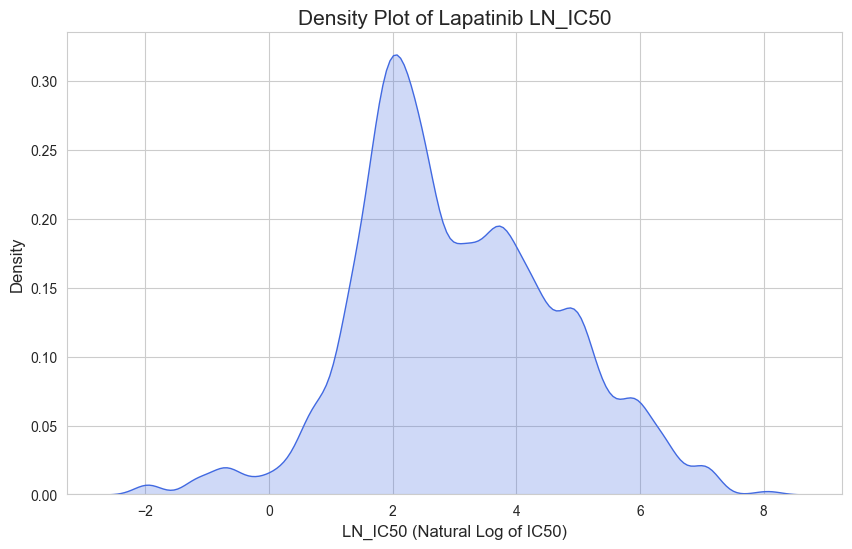

In [79]:
# Let us quickly check the distribution
df_response_lapatinib["LN_IC50"]

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.kdeplot(df_response_lapatinib["LN_IC50"], fill=True, color="royalblue", bw_adjust=0.5)

plt.title('Density Plot of Lapatinib LN_IC50', fontsize=15)
plt.xlabel('LN_IC50 (Natural Log of IC50)', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.show()

We see in the above plot that the density ressembles a mixture of different normal distributions. This suggests the dataset consits of several subpopulations.

We will investigate this with more elaborate models later.

# Loading and Preparing Data

We will now prepare the data for our analysis.

Workflow:
1) merge dataframe df_sample_info with df_expression_data
2) merge resulting dataframe with df_response_lapatinib

The result of the first merging step will be used to visualize the general structure of the cell line data. The second dataset will be used for the remaining analysis steps.

The following columns could be intresting for our models:

- CCLE_Name seems also to represent the type of tissue
- lineage
- sex
- source
- sample_collection_site seems also to represent the type of tissue.
- primary_disease
- age

We will only use the sample_collection_site for now.

## 1) Expression data and sample info data

We combine the dataset containing the gene expression data with the dataset containing the metadata about the cell lines.

In [80]:
# Due to the different identification systems for cell lines we extract the columns
# DepMap_ID and Sanger_Model_ID. Also we extract the column sample_collection_site
# for visualization of the dataset and for one of the subsequent models.
# All the other data we discard here for simplicity.
df_sample_info4merge = df_sample_info[['DepMap_ID', 
                                       'sample_collection_site', 
                                       'Sanger_Model_ID']]

# We use an inner joint since we are only interested in expression data for
# which we have an entry in the dataframe df_sample_info
df_expression_data_with_sample_info = df_expression_data.merge(df_sample_info4merge, 
                                                     on='DepMap_ID', 
                                                     how="inner")
l1 = df_sample_info.shape[0] # number of entries for which we have meta data
l2 = df_expression_data.shape[0] # number of entries for which we have gene expression data
l3 = df_expression_data_with_sample_info.shape[0] # number of entries for which we have both
print(f"Merging df_sample_info with {l1} entries with df_expression_data with {l2} entries resulted in {l3} entries in the merged dataset.(i.e. {l3} entries have expression data and meta data.)".format(l1, l2, l3)) 

num_of_different_sanger_ids = len(pd.unique(df_expression_data_with_sample_info['Sanger_Model_ID']))

print(f"Number of different sanger ids in merged dataset: {num_of_different_sanger_ids}".format(num_of_different_sanger_ids))

Merging df_sample_info with 1829 entries with df_expression_data with 1393 entries resulted in 1393 entries in the merged dataset.(i.e. 1393 entries have expression data and meta data.)
Number of different sanger ids in merged dataset: 821


Again note that some of the entries in dataset must have entries with the same Sanger ID. This might be a problem for our analysis.

To check this further we look at duplicate entries for the same cell lines. The relevance of this should be discussed.

In [81]:
# Filter out entries with duplicate Sanger ID
filt_dup = df_expression_data_with_sample_info.duplicated(subset=['Sanger_Model_ID'], keep=False)

df_expression_data_with_sample_info_duplicates = df_expression_data_with_sample_info[filt_dup]
df_expression_data_with_sample_info_no_duplicates = df_expression_data_with_sample_info[~filt_dup]

l1 = df_expression_data_with_sample_info_duplicates.shape[0]
l2 = df_expression_data_with_sample_info_no_duplicates.shape[0]
assert l1 + l2 == df_expression_data_with_sample_info.shape[0]
print(f"{l1} entries have duplicates and {l2} entries have no duplicates.".format(l1, l2))
df_expression_data_with_sample_info_no_duplicates.head(n=2)
df_expression_data_with_sample_info_duplicates.head(n=2)


573 entries have duplicates and 820 entries have no duplicates.


,DepMap_ID,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),...,AC090517.4 (54816),AL160269.1 (11046),ABCF2-H2BE1 (114483834),POLR2J3 (548644),H2BE1 (114483833),AL445238.1 (647264),GET1-SH3BGR (106865373),AC113348.1 (102724657),sample_collection_site,Sanger_Model_ID
1,ACH-001289,5.209843,0.545968,7.070604,2.538538,3.510962,0.0,0.176323,3.836934,4.200850,...,0.310340,0.000000,0.807355,4.704319,0.0,0.0,0.464668,0.070389,central_nervous_system,NaN
3,ACH-001538,5.726831,0.000000,7.086189,2.543496,3.102658,0.0,5.914565,6.099716,4.475733,...,0.263034,2.485427,0.713696,3.858976,0.0,0.0,0.000000,0.000000,biliary_tract,NaN


Duplicates could stem from subcell lines. However, we should keep this issue in mind and after discussing this point further it might be necessary to remove duplicates or better to keep them.

In [82]:
# We could do also some further quality checks such as checking for nan values or other unusual
# values in the dataset.

## 2) Drug response data

We take the merged dataset from the last section containing gene expression data with meta data and combine it with drug sensitivity data.

In [83]:
# We use an inner joint since we are only interested in data
# for which gene expression data and drug response data is available.
df_sample_all = df_response_lapatinib.merge(df_expression_data_with_sample_info, 
                           right_on='Sanger_Model_ID',
                           left_on='SANGER_MODEL_ID',
                           how='inner')

l1 = len(pd.unique(df_sample_all["CELL_LINE_NAME"])) # number of cell lines in resulting dataset
l2 = df_response_lapatinib.shape[0] # number of entries in the drug response dataset
l3 = df_sample_all.shape[0] # number of entries in resulting datast
l4 = l2 - l3 # Number of entries that got lost during the merging step.
l5 = len(pd.unique(df_sample_all["DepMap_ID"]))
l6 = len(pd.unique(df_sample_all["SANGER_MODEL_ID"]))
s = f"From the original {l2} data entries for lapatinib {l4} entries were discarded since no metadata was available.".format(l2, l4)
print(s)
print(f"This results in a dataset of {l3} entries for which we have expression data and drug response data for the drug of interest is available.".format(l3))

# Each entry corresponds to exactly one cell line, DepMap_ID and SANGER_MODEL_ID
assert l1 == l3 == l5 == l6

df_sample_all.head(n=2)

From the original 757 data entries for lapatinib 183 entries were discarded since no metadata was available.
This results in a dataset of 574 entries for which we have expression data and drug response data for the drug of interest is available.


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,...,AC090517.4 (54816),AL160269.1 (11046),ABCF2-H2BE1 (114483834),POLR2J3 (548644),H2BE1 (114483833),AL445238.1 (647264),GET1-SH3BGR (106865373),AC113348.1 (102724657),sample_collection_site,Sanger_Model_ID
0,GDSC2,282,13320559,749709,HCC1954,SIDM00872,BRCA,1558,Lapatinib,"EGFR, ERBB2",...,0.111031,0.084064,2.266037,5.173527,0.0,0.0,0.286881,0.0,breast,SIDM00872
1,GDSC2,282,13320592,749710,HCC1143,SIDM00866,BRCA,1558,Lapatinib,"EGFR, ERBB2",...,0.176323,0.389567,1.505891,5.798828,0.0,0.0,0.367371,0.0,breast,SIDM00866


We could consider using all 757 data entries for some part of the analysis. Again it should be discussed why for some cell lines no metadata/gene expression data was available.

# Structure of cell line data

We will perform PCA followed by UMAP to reduce the dimensionality.
The resulting projected data will be visualized and we visually inspect if the features such as cell type are preserved.

1) PCA (Principal Component Analysis) serves for linear noise reduction and a first compression step in the analysis. It is recommended to work on normalized data. Since in our data set the gene expression data is log-transformed we don't need any further transformation. Often the set of genes is also reduced to highly variable genes. We will not do this here to keep the code simple.
2) UMAP (Uniform Approximation and Projection method) after PCA tends to perform better than on the original data. (UMAP reduces the data similar to PCA to a lower dimensional space but is non-linear in nature.)

Sources:
 - "Current best practices in single-cell RNA-seq analysis: a tutorial" (Luecken MD & Theis FJ,
   2019)
   - contains more useful advices for data cleaning such as regressing out technical and biological effects.
   - reduction to HGV (highly variable genes)
   - They regard UMAP as best practice for exploratory data analysis 
 - "Single-cell RNA sequencing data dimensionality reduction" (Zagopoulos VL et al, 2025)



### Meaning of the metric: log2(TPM+1)

- Large log2(TPM+1) values mean that a specific gene is being expressed at a higher level (more mRNA transcripts are present) in that cell line compared to genes with lower values. The +1 is added to preven log zero errors. TPM stands for Transcripts Per Million. It is a normalization method for RNA-seq data that accounts for two things:
  1) Gene Length: Longer genes naturally produce more fragments; TPM corrects for this so you can compare a long gene to a short gene.
  2) Sequencing Depth: Some samples are sequenced more deeply than others; TPM ensures that the total sum of expression in every sample adds up to 1,000,000.

In [84]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap

## General Structure of cell line data

In [85]:
df_expression_data_with_sample_info_no_duplicates.head(n=2)

,DepMap_ID,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),...,AC090517.4 (54816),AL160269.1 (11046),ABCF2-H2BE1 (114483834),POLR2J3 (548644),H2BE1 (114483833),AL445238.1 (647264),GET1-SH3BGR (106865373),AC113348.1 (102724657),sample_collection_site,Sanger_Model_ID
0,ACH-001113,4.990501,0.0,7.273702,2.765535,4.480265,0.028569,1.269033,3.058316,6.483171,...,0.111031,0.150560,1.427606,5.781884,0.0,0.000000,0.799087,0.0,lung,SIDM01226
2,ACH-001339,3.779260,0.0,7.346425,2.339137,4.254745,0.056584,1.339137,6.724241,3.671293,...,0.176323,0.042644,1.384050,4.931683,0.0,0.028569,0.263034,0.0,skin,SIDM00514


In [86]:
# We get the names of gene expression columns
numeric_col_names4pca = df_expression_data.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Except the first column all remaining columns correspond to expression data
# of genes
assert len(numeric_col_names4pca) == df_expression_data.shape[1] -1


In [87]:
# We choose the columns for pca
features = df_expression_data_with_sample_info_no_duplicates[numeric_col_names4pca]

# Standardization of the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

We use an elbow plot to choose visually an appropriate cutoff component for our PCA.

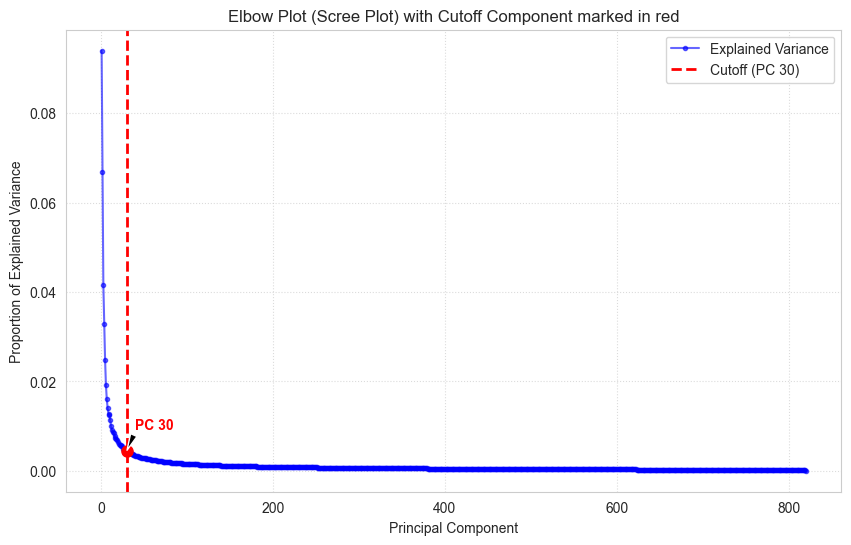

In [88]:
def create_elbow_plow(scaled_data):
    # Fit PCA
    pca = PCA()
    pca.fit(scaled_data)
    
    # Get the explained variance ratio
    # Each value represents the proportion of total variance captured by that component
    explained_variance = pca.explained_variance_ratio_
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'bo-', markersize=3, alpha=0.6, label='Explained Variance')

    # Color and highlight the PCA component used for the cutoff
    cutoff = 30
    
    if len(explained_variance) >= cutoff:
        # Add a red vertical dashed line at the cutoff component
        plt.axvline(x=cutoff, color='red', linestyle='--', linewidth=2, label=f'Cutoff (PC {cutoff})')
    
        # Note: index is cutoff-1 because Python is 0-indexed
        plt.plot(cutoff, explained_variance[cutoff-1], 'ro', markersize=8)
    
        plt.annotate(f'PC {cutoff}', 
                     xy=(cutoff, explained_variance[cutoff-1]), 
                     xytext=(cutoff + 10, explained_variance[cutoff-1] + 0.005),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                     color='red', fontweight='bold')

    plt.title('Elbow Plot (Scree Plot) with Cutoff Component marked in red')
    plt.xlabel('Principal Component')
    plt.ylabel('Proportion of Explained Variance')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.show()

create_elbow_plow(scaled_data)

In [89]:
# PCA Analysis (We reduce to 30 components.)
pca = PCA(n_components=30)
pca_result = pca.fit_transform(scaled_data)

In [90]:
# Run UMAP on the reduced compenents
# n_neighbors = 15 seems to be default in many programs (like scanpy)
# similar min_dist=0.1 is the default in scanpy
# Source: "SCANPY: large-scale single-cell gene expression data analysis" (Wolf, F.A. Angerer, P. & Theis F.J. , 2018)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(pca_result)

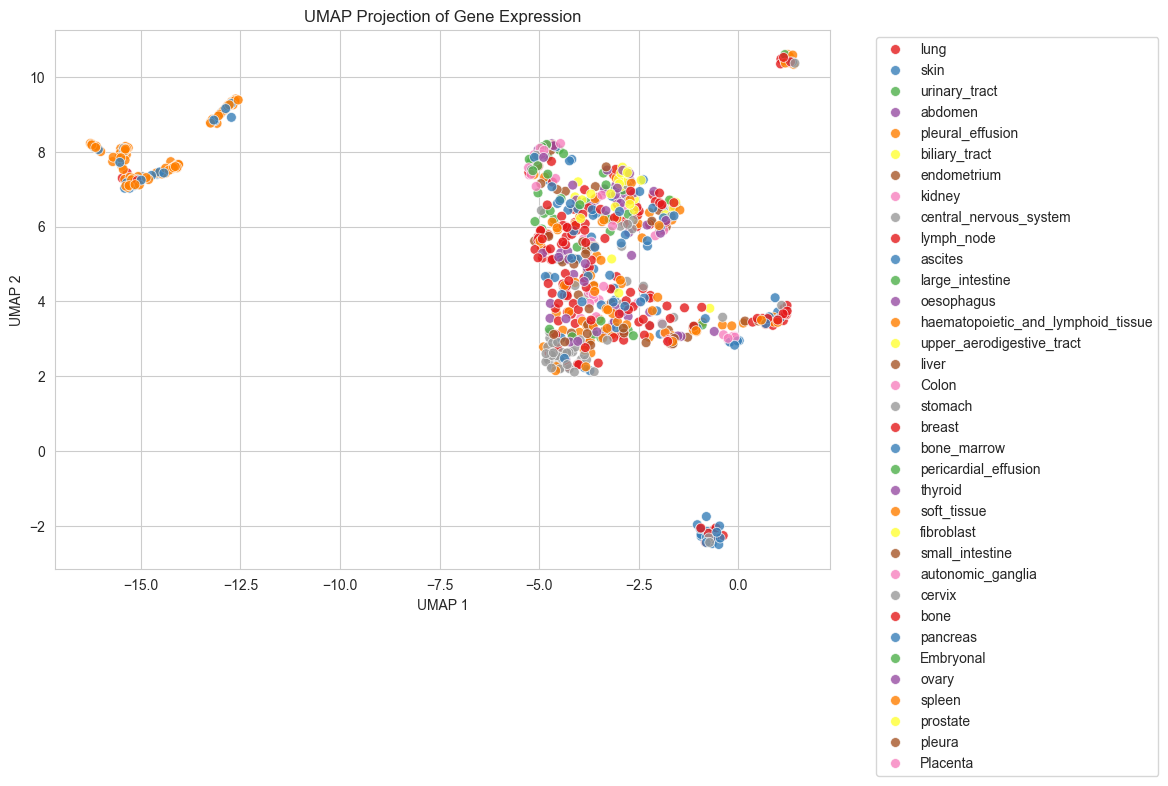

In [91]:
# select the column 
col4hue = 'sample_collection_site'

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=embedding[:, 0], 
    y=embedding[:, 1], 
    hue=df_expression_data_with_sample_info_no_duplicates[col4hue],  # Color by tissue
    palette='Set1',
    s=50, alpha=0.8
)
plt.title('UMAP Projection of Gene Expression')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

## Structure of cell line data in a specific type of tissue

Let us see if the clustering is able to differentiate between different tissue types.

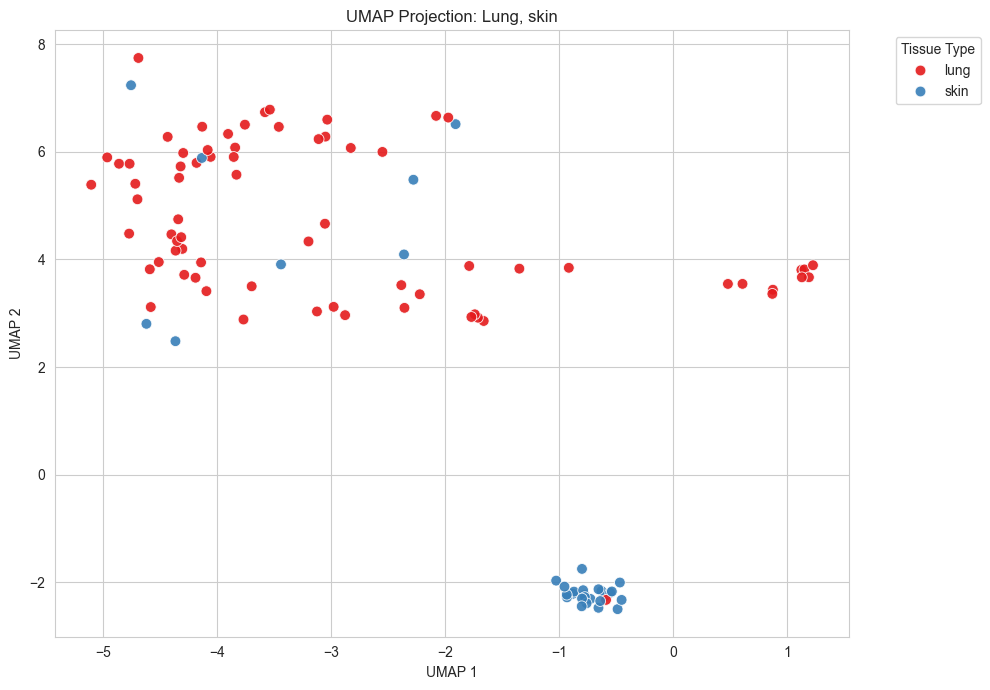

In [92]:
# We want to have a look at the following two tissues
target_tissues = ['lung', 'skin']
col4tissue = 'sample_collection_site'
col4hue = col4tissue

mask = df_expression_data_with_sample_info_no_duplicates[col4hue].isin(target_tissues)

# Apply the mask to the UMAP embedding
filtered_embedding = embedding[mask]
# and the metadata
filtered_metadata = df_expression_data_with_sample_info_no_duplicates[mask]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=filtered_embedding[:, 0], 
    y=filtered_embedding[:, 1], 
    hue=filtered_metadata[col4hue],  # Use the filtered metadata for coloring
    palette='Set1',
    s=60, 
    alpha=0.9,
    edgecolor='w'
)

plt.title(f'UMAP Projection: {", ".join(target_tissues).capitalize()}')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, title='Tissue Type')
plt.tight_layout()
plt.show()

We see that the clustering seems to separate the two sample collection sites well. This alligns with our expectations since different tissues should have
different gene expression profiles. We could now go on and test this more systematically for different tissue types.

Next steps:

    - We can investigate systematically in how far clusters correspond to tissue types.
    - We can use some unsupervized clustering algorithms to identify the number of clusters.
    - We can check in how far clusters are related to drug sensitivity data by coloring them accordingly.

## Lapatinib

In the previous section we worked with the complete gene expression data set. Now we want to look at the subset containing data for drug sensitivity to Lapatinib. For this purpose we recreate the PCA on this subset. Alternatively, we could use the previous PCA and restrict it to this data. But that is a little bit more complicated so we go with the easy solution.

Lapatinib (brand name Tykerb) is a targeted therapy medication used primarily to treat specific types of advanced or metastatic breast cancer.

Unlike traditional chemotherapy that attacks all rapidly dividing cells, Lapatinib is a tyrosine kinase inhibitor. It works by "blocking" specific signals inside cancer cells that tell them to grow and multiply.

### Meaning of the metric: LN_IC 50
- IC50: The concentration of a drug required to inhibit biological activity by 50%.
   - Higher IC50 = Less Sensitive
   - Lower IC50 = More Sensitive
- LN_IC50: The natural log of that value. It follows the same logic.
- In pharmacology, the lower the IC 50 the more potent the drug is against that specific cell.

In [93]:
# Let us assume we are primarily interested in lung cancers
col4tissue = 'sample_collection_site'
# tissues_of_interest = ["lung"]

# We choose all columns as featues which are numeric
features = df_sample_all[numeric_col_names4pca]

# Standardization of the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

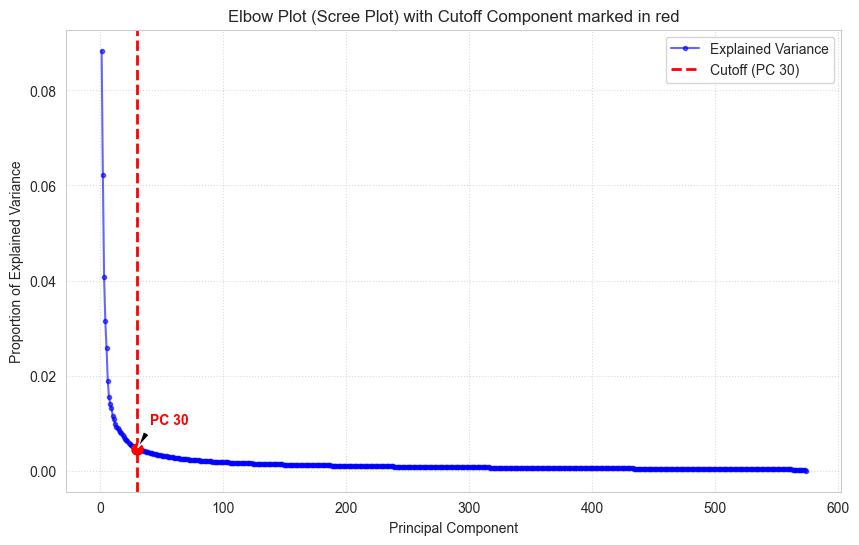

In [94]:
create_elbow_plow(scaled_data)

In [95]:
# PCA Analysis (We reduce to 30 components)
pca = PCA(n_components=30)
pca_result = pca.fit_transform(scaled_data)

# Run UMAP on the reduced compenents
# We use again the same hyperparameters as above.
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(pca_result)

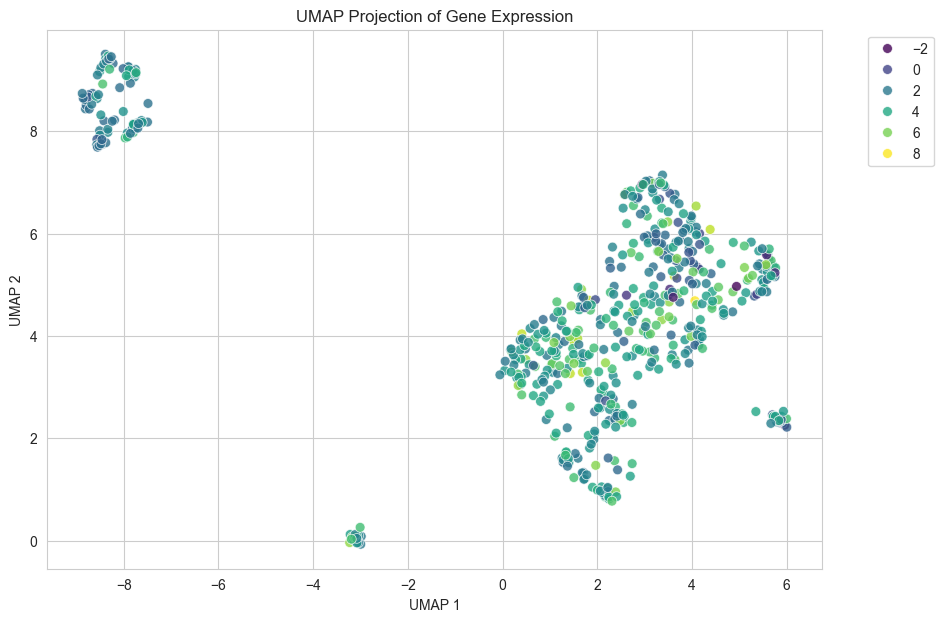

In [96]:
# select the column 
col4hue = 'LN_IC50'

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=embedding[:, 0], 
    y=embedding[:, 1], 
    hue=df_sample_all[col4hue],  # Color by tissue
    palette='viridis',
    s=50, alpha=0.8
)
plt.title('UMAP Projection of Gene Expression')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)

No extreme differences are visible between the clusters. However, we could refine this analysis.

Possible next steps:

    - Run unsupervized clustering on this dataset.
    - Run ANOVA on the identified clusters to see if any cluster is associated with a significant change in drug sensitivity for Lapatinib

# Identification of expression-based biomarkers for the drug Lapatinib

We will now continue with modeling drug sensitivity based on gene expression. We apply two regression strategies that differ in how they handle high-dimensional gene expression data:

    1) PCR (Principal Component Regression) as a purely statistical method.
    2) ElasticNet as a Statistical Machine Learning Approach

I try to use a more statistical approach for the first method and a Machine Learning approach for the second. However, I believe the difference is to a certain degree subjective since we could for example split the dataset into training and test data for PCR as well. And on the other hand many of the typical Ordinary Least Square methods can be applied to Elastic Nets as well.

In [97]:
# We use an elastic net for our analysis‚
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import train_test_split

In [98]:
# Remember the dataset is restricted to the drug Lapatinib
pd.unique(df_sample_all['DRUG_NAME'])

<StringArray>
['Lapatinib']
Length: 1, dtype: str

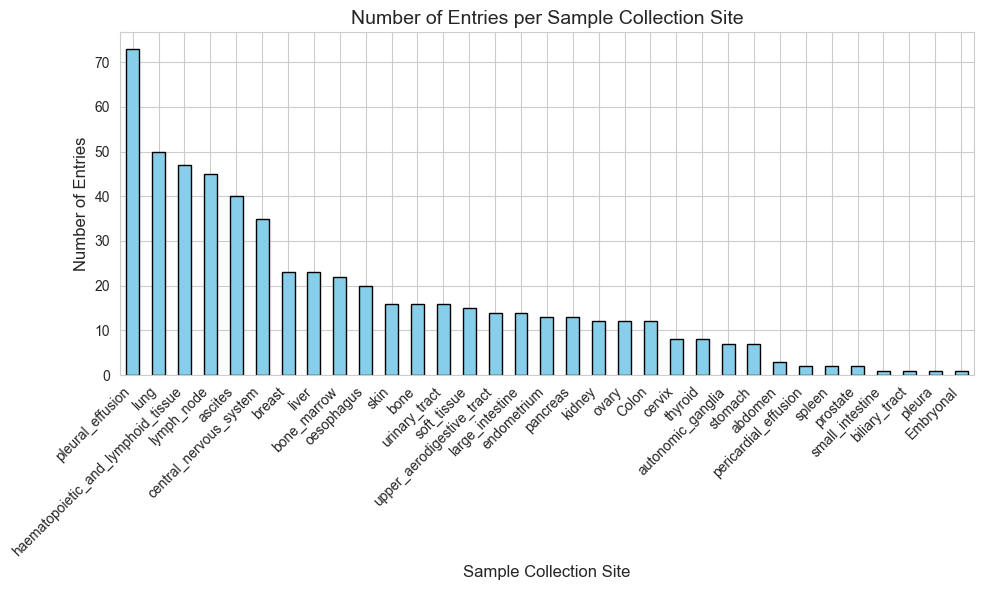

In [99]:
# Count the occurrences of each sample collection site
site_counts = df_sample_all['sample_collection_site'].value_counts()

# Sort the counts in descending order for better visualization
site_counts = site_counts.sort_values(ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
site_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Add labels and title
plt.title('Number of Entries per Sample Collection Site', fontsize=14)
plt.xlabel('Sample Collection Site', fontsize=12)
plt.ylabel('Number of Entries', fontsize=12)

# Rotate labels to ensure they are readable and not truncated
plt.xticks(rotation=45, ha='right')

# Adjust layout and save
plt.tight_layout()
plt.savefig('sample_collection_site_counts.png')

Suprisingly, most sample are from pleural effusion and not from breast tissue.

A pleural effusion, often referred to as "water on the lungs," is the abnormal buildup of excess fluid in the pleural space—the thin, fluid-filled cavity between the layers of tissue (pleura) 
that line your lungs and the inside of your chest wall.

## PCR (Principal Component Regression)

Since we have many more genes than samples we somehow need to increase our statistical power to have the chance to find something. Furthermore, if too many covariates are correlated the numeric solvers for Linear Regression become unstable. Performing PCA before the regression step is an easy approach to mitigate this problem since the resulting PCA components will be orthogonal. However, we face afterwards the problem which conclusions we draw from a PCA component that appears as a significant covariate in the regression analysis. We will use the loadings to perform a KEGG pathway analysis attempting to gain some biological insight from these components.

In [100]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests

In [101]:
# Let us look first at the tissues
print(df_sample_all[col4tissue].value_counts())

sample_collection_site
pleural_effusion                      73
lung                                  50
haematopoietic_and_lymphoid_tissue    47
lymph_node                            45
ascites                               40
central_nervous_system                35
breast                                23
liver                                 23
bone_marrow                           22
oesophagus                            20
skin                                  16
bone                                  16
urinary_tract                         16
soft_tissue                           15
upper_aerodigestive_tract             14
large_intestine                       14
pancreas                              13
endometrium                           13
kidney                                12
ovary                                 12
Colon                                 12
cervix                                 8
thyroid                                8
autonomic_ganglia                 

Since many tissues just appear a couple of times we group them together into Other.

In [102]:
# Identify the frequency of each tissue
tissue_counts = df_sample_all[col4tissue].value_counts()

# We use an arbitray treshold of 5 samples
threshold = 5
rare_tissues = tissue_counts[tissue_counts < threshold].index

# We create a new column where rare tissues are grouped into 'Other'
df_sample_all['Tissue_Grouped'] = df_sample_all[col4tissue].apply(
    lambda x: 'Other' if x in rare_tissues else x
)

print(df_sample_all['Tissue_Grouped'].value_counts())

# We update the tissue column
col4tissue = 'Tissue_Grouped'

l = len(pd.unique(df_sample_all[col4tissue]))
l

Tissue_Grouped
pleural_effusion                      73
lung                                  50
haematopoietic_and_lymphoid_tissue    47
lymph_node                            45
ascites                               40
central_nervous_system                35
breast                                23
liver                                 23
bone_marrow                           22
oesophagus                            20
skin                                  16
bone                                  16
urinary_tract                         16
soft_tissue                           15
upper_aerodigestive_tract             14
large_intestine                       14
Other                                 13
pancreas                              13
endometrium                           13
kidney                                12
ovary                                 12
Colon                                 12
cervix                                 8
thyroid                                8
a

/var/folders/j1/yfk1ym2s5kx64sfymwdmqhjm0000gn/T/ipykernel_59346/348686653.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sample_all['Tissue_Grouped'] = df_sample_all[col4tissue].apply(


26

In [103]:
df_sample_all.shape

(574, 19200)

In [104]:
# Standardize the numeric data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_sample_all[numeric_col_names4pca])

# PCA
# We have 574 samples and 33 covariates coming from the tissue. To obtain reasonable stat. power
# we keep the top 20 components resulting in roughly 574/(26+20) = 12.47 samples per predictor
pca = PCA(n_components=20) 
pca_features = pca.fit_transform(scaled_data)

In [105]:
# How much variance the pca explains
pca.explained_variance_ratio_.sum()

np.float64(0.4062945767498931)

In this model we also will take the type of tissue into account since I assume that we are interested in biomarkers are independent of the type of tissue. But this could be discussed, too and depends on the application. Therefore, we do the following:
1) model 1: We fit an ANOVA model on the different tissue types.
2) model 2: We fit an ANCOVA model on the different tissue type and the top PCA components.
3) We run a Partial F test comparing the two nested models. If the Partial F-test is significant adding the PCA components significantly increases the model fit and confirms that some of the genes indeed help to explain some of the variability of the data.

In [106]:
pca_df = pd.DataFrame(
    pca_features, 
    columns=[f'PC{i+1}' for i in range(pca_features.shape[1])],
    index=df_sample_all.index
)

# 1. Prepare Dummy Variables for Tissue
# We use drop_first=True to obtain linearly independent columns
tissue_dummies = pd.get_dummies(df_sample_all[col4tissue], prefix='tissue', drop_first=True)

# 2. Fit the Base Model (Tissue only)
X_base = sm.add_constant(tissue_dummies.astype(float))
y = df_sample_all['LN_IC50']
model_base = sm.OLS(y, X_base).fit()

# 3. Fit the Bigger Model (Tissue + PCA Components)
X_full = pd.concat([tissue_dummies, pca_df], axis=1)
X_full = sm.add_constant(X_full.astype(float))
model_full = sm.OLS(y, X_full).fit()

# 4. Perform the F-test
# anova_lm compares nested models and returns the F-statistic and p-value
anova_results = anova_lm(model_base, model_full)

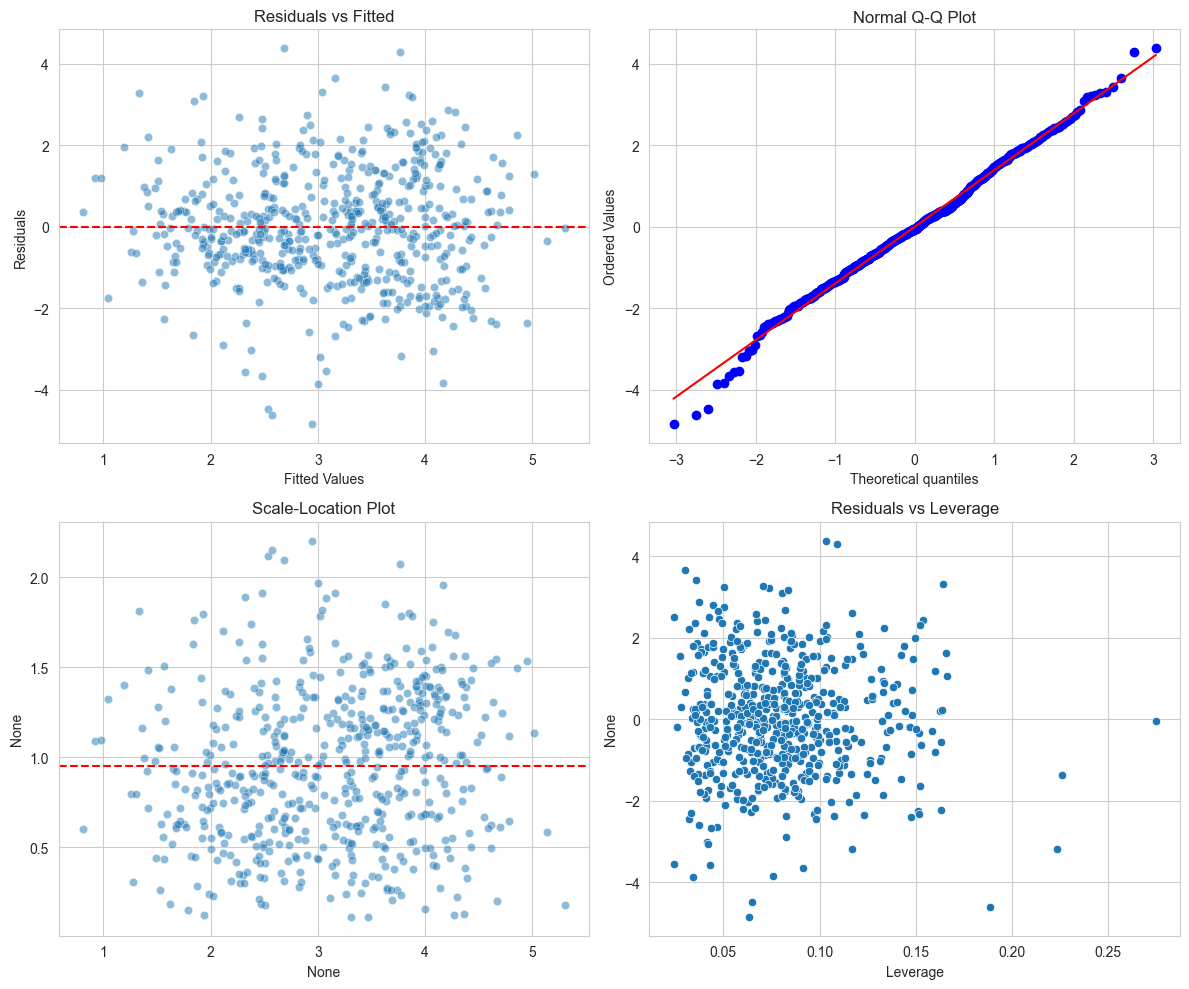

In [107]:
import scipy.stats as stats

def plot_model_diagnostics(model):
    """
    Generates 4 diagnostic plots for an OLS model.
    """
    # 1. Calculate residuals
    residuals = model.resid
    fitted = model.fittedvalues
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Plot 1: Residuals vs Fitted (Checks Linearity and Homoscedasticity)
    sns.scatterplot(x=fitted, y=residuals, ax=axes[0, 0], alpha=0.5)
    axes[0, 0].axhline(y=0, color='red', linestyle='--')
    axes[0, 0].set_title('Residuals vs Fitted')
    axes[0, 0].set_xlabel('Fitted Values')
    axes[0, 0].set_ylabel('Residuals')
    
    # Plot 2: Normal Q-Q Plot (Checks Normality of Residuals)
    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('Normal Q-Q Plot')
    
    # Plot 3: Scale-Location Plot (Checks Homoscedasticity)
    # sqrt(abs(residuals))
    sqrt_abs_resid = np.sqrt(np.abs(residuals))
    sns.scatterplot(x=fitted, y=sqrt_abs_resid, ax=axes[1, 0], alpha=0.5)
    axes[1, 0].axhline(y=np.mean(sqrt_abs_resid), color='red', linestyle='--')
    axes[1, 0].set_title('Scale-Location Plot')
    
    # Plot 4: Residuals vs Leverage (Checks for Influential Outliers)
    # Using Cook's Distance
    infl = model.get_influence()
    cooks = infl.cooks_distance[0]
    sns.scatterplot(x=model.get_influence().hat_matrix_diag, y=residuals, ax=axes[1, 1])
    axes[1, 1].set_title('Residuals vs Leverage')
    axes[1, 1].set_xlabel('Leverage')
    
    plt.tight_layout()
    plt.show()

# Call this on your 'model_full'
plot_model_diagnostics(model_full)

In [108]:
print("--- Base Model Summary (Tissue Only) ---")
print(f"R-squared: {model_base.rsquared:.4f}")

print("\n--- Full Model Summary (Tissue + PCs) ---")
print(f"R-squared: {model_full.rsquared:.4f}")

print("\n--- ANOVA F-Test Results ---")
print(anova_results)

# Interpretation
p_value = anova_results.loc[1, 'Pr(>F)']
if p_value < 0.05:
    print(f"\nResult: Significant (p={p_value:.4e}). The PCA components provide additional predictive power.")
else:
    print(f"\nResult: Not Significant (p={p_value:.4f}). The PCA components do not significantly improve the model.")

--- Base Model Summary (Tissue Only) ---
R-squared: 0.1535

--- Full Model Summary (Tissue + PCs) ---
R-squared: 0.2824

--- ANOVA F-Test Results ---
   df_resid          ssr  df_diff     ss_diff         F        Pr(>F)
0     548.0  1305.689506      0.0         NaN       NaN           NaN
1     528.0  1106.869328     20.0  198.820178  4.742071  1.257767e-10

Result: Significant (p=1.2578e-10). The PCA components provide additional predictive power.


- Tissue type alone explains about 15% of the variance in drug sensitivity (LN_IC50). We use this as a baseline.
- By adding the PCA components, the explained variance jumps to 28%.
- The PCA components provide a significant improvement to the model

Now let us have a closer look at the output of the model. We start by filtering out the significant PCA components.

In [109]:
# 1. Extract coefficients, std errors, and p-values for PCA components only
# We filter the model parameters to only look at columns starting with 'PC'
pca_cols = [c for c in X_full.columns if c.startswith('PC')]

results_df = pd.DataFrame({
    'Beta': model_full.params[pca_cols],
    'Std_Err': model_full.bse[pca_cols],
    'P_Value': model_full.pvalues[pca_cols]
})

# 2. Apply Benjamini-Hochberg Correction
# 'fdr_bh' is the standard implementation of the BH procedure
rejected, pvals_corrected, _, _ = multipletests(
    results_df['P_Value'], 
    alpha=0.05, 
    method='fdr_bh'
)

results_df['P_Value_Adj'] = pvals_corrected
results_df['Significant_BH'] = rejected

# 3. Filter for only the significant components
significant_pcs = results_df[results_df['Significant_BH'] == True].sort_values('P_Value_Adj')

print("--- Significant PCA Components (After BH Correction) ---")
if significant_pcs.empty:
    print("No PCA components remained significant after BH correction.")
else:
    print(significant_pcs[['Beta', 'Std_Err', 'P_Value', 'P_Value_Adj']])

--- Significant PCA Components (After BH Correction) ---
          Beta   Std_Err       P_Value  P_Value_Adj
PC2   0.014752  0.002758  1.317080e-07     0.000003
PC7   0.018775  0.004175  8.491638e-06     0.000085
PC3  -0.007708  0.002662  3.944127e-03     0.026294
PC11 -0.013467  0.004919  6.398112e-03     0.031991


- PC2 and PC7: As the molecular signatures represented by PC2 and PC7 increase, the LN_IC50 increases. Therefore, these components are associated with drug resistance. (Or more precisily, positive loadings are associated with drug resistance.)
- PC3 and PC11: As the signature of PC3 increases, LN_IC50 decreases. PC3 represents a signature associated with drug sensitivity (increased potency).

Now let us have a look at the distribution of the loadings of these PCA components.

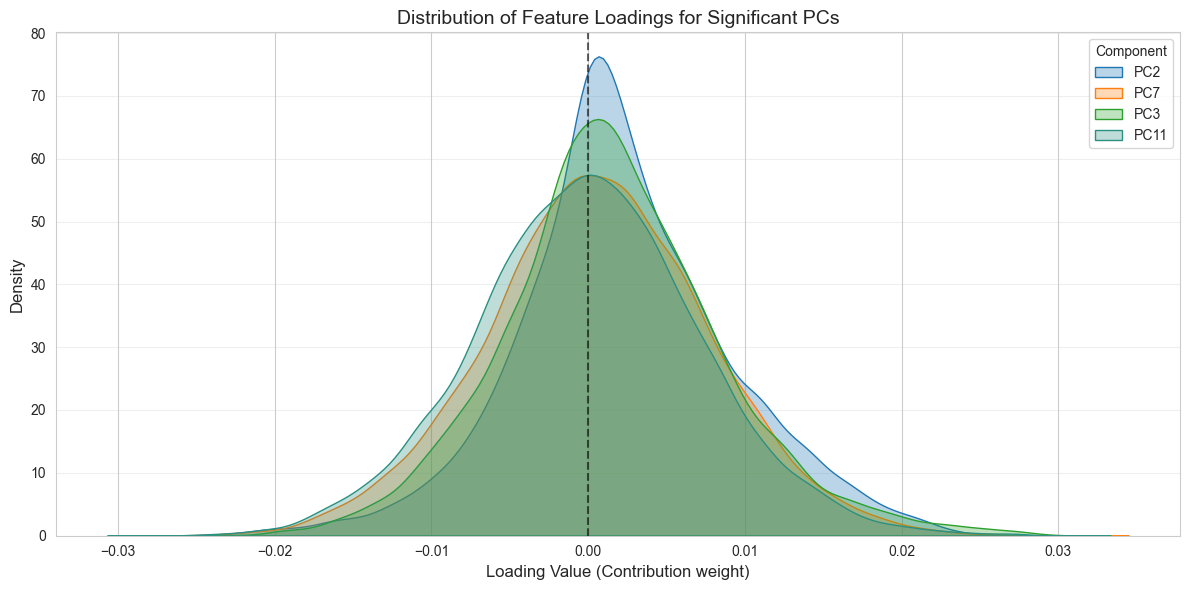

In [110]:
# 1. Extract the loadings from the PCA object
# pca.components_ has shape (n_components, n_features)
loadings = pca.components_
feature_names = numeric_col_names4pca

# 2. Create a DataFrame for the significant loadings
df_loadings = pd.DataFrame({
    'PC2': loadings[1],
    'PC7': loadings[6],
    'PC3': loadings[2],
    'PC11': loadings[10]
}, index=feature_names)

# 3. Plotting the distributions
plt.figure(figsize=(12, 6))

# Define colors for the components
colors = {'PC2': '#1f77b4', 'PC7': '#ff7f0e', 'PC3': '#2ca02c', 'PC11': '#2a9081'}

for pc in ['PC2', 'PC7', 'PC3', 'PC11']:
    sns.kdeplot(df_loadings[pc], label=pc, color=colors[pc], fill=True, alpha=0.3)

# Add reference line at 0
plt.axvline(x=0, color='black', linestyle='--', alpha=0.6)

# Labels and Title
plt.title('Distribution of Feature Loadings for Significant PCs', fontsize=14)
plt.xlabel('Loading Value (Contribution weight)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Component')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('pca_loadings_distribution.png')

We use a KEGG pathway analysis to see if some genes are overrepresented in certain pathways.

In [111]:
import gseapy as gp

def run_pc_kegg_analysis(pca_model, pc_label, feature_names, gene_set='KEGG_2021_Human'):
    """
    Runs KEGG pathway analysis for a specific Principal Component.
    """
    # 1. Map label to index
    idx = int(pc_label.replace('PC', '')) - 1
    
    # 2. Extract and Clean Loadings
    loadings = pd.Series(pca_model.components_[idx], index=feature_names)
    loadings.index = loadings.index.str.split(' ').str[0]
    
    # 3. Handle Duplicate Values (Jittering)
    # Adding a tiny amount of noise ensures every rank is unique
    # 1e-10 is small enough not to change biological meaning
    rng = np.random.default_rng(42)
    loadings = loadings + rng.standard_normal(len(loadings)) * 1e-10
    
    # Sort for Prerank GSEA
    ranked_genes = loadings.sort_values(ascending=False)
    
    print(f"\n--- Running KEGG Analysis for {pc_label} ---")
    
    try:
        results = gp.prerank(
            rnk=ranked_genes,
            gene_sets=gene_set,
            threads=4, 
            permutation_num=1000, 
            outdir=None, 
            seed=42
        )
        
        res_df = results.res2d
        # I rename columns here since certain column names are expected later on
        res_df = res_df.rename(columns={'FDR q-val': 'Adjusted P-value'})
        significant_pathways = res_df[res_df['Adjusted P-value'] < 0.05].head(10) 
        print(significant_pathways[['Term', 'NES', 'Adjusted P-value']])
        results.res2d = res_df
        gp.plot.dotplot(results.res2d, title=f'KEGG: {pc_label}')
        
    except Exception as e:
        print(f"Error running GSEA for {pc_label}: {e}")
        return None


--- Running KEGG Analysis for PC7 ---
                                          Term       NES Adjusted P-value
0                                  Spliceosome -2.705532              0.0
1                              DNA replication -2.693246              0.0
2                                   Cell cycle -2.474391              0.0
3                    Oxidative phosphorylation  2.191972              0.0
4                     Type I diabetes mellitus  2.176063              0.0
5            Ascorbate and aldarate metabolism   2.16828              0.0
6  Protein processing in endoplasmic reticulum  2.163935              0.0
7             Herpes simplex virus 1 infection -2.133292         0.000276
8                    mRNA surveillance pathway -2.106177         0.000221
9         Porphyrin and chlorophyll metabolism   2.08166         0.000189


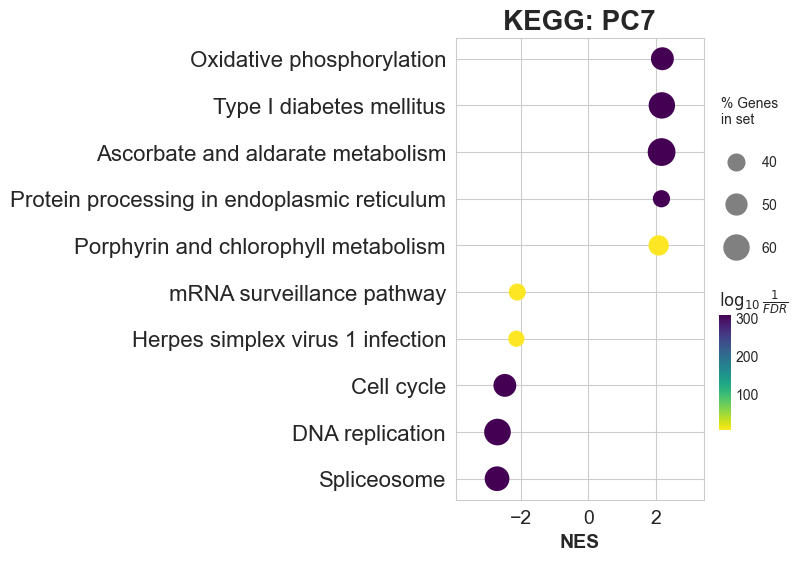

In [112]:
# We will restrict the analysis here to component 7 to keep the code shorter and 
# since it had the largest effect size
# To see the other components replace with one of these ['PC2', 'PC3', 'PC7', 'PC11']
run_pc_kegg_analysis(pca, 'PC7', numeric_col_names4pca)

Meaning of the colors:
- NES = Normalized Enrichment Score
- Yellow (Positive NES)
- Blue (Negative NES)
- Size of dots represents the Gene Ratio or the number of genes in the pathway that were found in the dataset.

- PC7 has a positive Beta coefficient (meaning higher PC7 = higher LN_IC50 = Drug Resistance) in the model.
- The pathways with a positive NES (Normalized Enrichment Score) are the drivers of drug resistance.
- Negative NES means these pathways are enriched in the negative loadings of PC7, positive NES means these pathways are enriched in the positive loading.
- Since the positive side of PC7 drives resistance, the negative side (where these pathways sit) represents Drug Sensitivity.
- Negative NES are associated with the "low" side of PC7. Since PC7 overall increases IC50, these negative pathways represent the vulnerabilities the drug targets.
    - Spliceosome, DNA Replication, & Cell Cycle: These are the "proliferative machinery" of the cell.
    - Interpretation: The drug might be more effective against cells that are rapidly dividing and heavily reliant on RNA splicing and DNA replication. This is a common profile for drugs inhibiting some part of the cell cycle.

In [113]:
# We also print the genes with the largest loading in the PCA
pc = 'PC7'
print(f"\n{pc} Drivers:")
top_pos = df_loadings[pc].sort_values(ascending=False).head(5)
top_neg = df_loadings[pc].sort_values(ascending=True).head(5)
print("  Top Positive:", top_pos.index.tolist())
print("  Top Negative:", top_neg.index.tolist())


PC7 Drivers:
  Top Positive: ['DNAJB9 (4189)', 'MUC13 (56667)', 'GJB1 (2705)', 'CCPG1 (9236)', 'HNF1A (6927)']
  Top Negative: ['S1PR5 (53637)', 'DLK2 (65989)', 'CDC20 (991)', 'FZD2 (2535)', 'PTK7 (5754)']


Since we run also a second analysis we leave the analysis here. But we could now continue looking at the enriched pathways of the other components and decide together with someone having more knowledge about
cancer biology if these results add up.

#### Other PCA components

In [114]:
# run_pc_kegg_analysis(pca, 'PC2', numeric_col_names4pca)
# run_pc_kegg_analysis(pca, 'PC3', numeric_col_names4pca)
# run_pc_kegg_analysis(pca, 'PC11', numeric_col_names4pca)

## Elastic Net

Elastic Net is a hybrid approach combining Lasso (L penalty) and Ridge (L penalty) regression.

It has the following parameter:

    1) l1_ratio: This parameter controls the mix. A ratio of 1 is pure Lasso (which forces irrelevant coefficients to exactly zero, effectively performing feature selection), while lower values incorporate Ridge (which keeps correlated features together).
    2) Instead of guessing the best parameters, this automatically performs 5-fold cross-validation to find the optimal α (penalty strength) and l1 ratio.

Elastic Net (especially with higher l ratios) promotes sparsity. Therefore, many coefficients will be pushed exactly to 0.

"CV" stands for Cross-Validation.

- Lasso: Excellent for feature selection because it sets unimportant coefficients to zero. However, it struggles if you have highly correlated features (e.g., genes that work together in the same pathway).
- Great at handling correlated features by shrinking their coefficients toward each other, but it doesn't perform feature selection (it rarely sets coefficients to zero).

Our elastic could also include the tissue information. We will not do this here to keep the complexity of the project managable and appropriate for a homework. If we would incorporate the tissue information we also would need to be careful with the "other"-column in the test and training dataset. Also we should think about if we use the tissue information for the split into training and test data.

In [115]:
# Select columns for the model
X = df_sample_all[numeric_col_names4pca] 
y = df_sample_all["LN_IC50"]

# Split the data FIRST (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Size of training dataset: ")
print(X_train.shape)
print("Size of test dataset: ")
print(X_test.shape)

Size of training dataset: 
(459, 19177)
Size of test dataset: 
(115, 19177)


We have many more features than samples. We could try to mitigate this problem
by filtering out some low-variance genes. I will not to do this here.

In [116]:
# Scale based ONLY on the training data to avoid "information leakage"
# Gene expression scales vary; standardizing is critical for Elastic Net
# Standard scaler scales the data to have mean zero and variance one
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Remark: we use the mean and variance of the training dataset here
# This is good practice since should not use the test data set for inference
X_test_scaled = scaler.transform(X_test)

# Fit the model on training data
# l1_ratio=0.5 is a balance between Lasso (feature selection) and Ridge
# The parameter l1_ratio controls the mix between lasso (=1) and ridge (=0)
# The parameter defines the mix ratios to be tried out
# cv = 10: means 10-fold cross validation
model = ElasticNetCV(l1_ratio=[.01, .05, .1, .5, .7, .9, .95, .99, 1], 
                     cv=10, 
                     max_iter=10000,
                     n_jobs=-1)
model.fit(X_train_scaled, y_train)

,"l1_ratio l1_ratio: float or list of float, default=0.5Float between 0 and 1 passed to ElasticNet (scaling betweenl1 and l2 penalties). For ``l1_ratio = 0``the penalty is an L2 penalty. For ``l1_ratio = 1`` it is an L1 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1 and L2This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.","[0.01, 0.05, ...]"
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path, used for each l1_ratio... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"verbose verbose: bool or int, default=0Amount of verbosity.",0


In [117]:
# Extract Biomarkers
coefficients = pd.Series(model.coef_, index=X.columns)
biomarkers = coefficients[coefficients != 0].sort_values()

print(f"Number of biomarkers identified: {len(biomarkers)}")

Number of biomarkers identified: 101


In [118]:
# Let us see which hyperparameters the mode chose
print(f"The best L1 Ratio: {model.l1_ratio_}")

The best L1 Ratio: 0.5


An L1 ratio close to 0.5 indicates that the model tries to balance out Ridge regression and Lasso regression. 

In [119]:
mi = np.round(np.min(model.alphas_), 3)
ma = np.round(np.max(model.alphas_), 3)
print(f"Alphas tested by the model were between {mi} and {ma}".format(mi, ma))
print(f"The best Alpha (penalty strength): {model.alpha_}")

Alphas tested by the model were between 0.001 and 55.475
The best Alpha (penalty strength): 0.27483269830975576


We see that the penalty parameter is not at the edge of the tested values. It suggests a moderate amount of penalty.

In [120]:
# The R 2 Score: Check model.score(X_scaled, y). 
# If it's very low (e.g., < 0.2), the linear relationship between 
# expression and sensitivity is weak for this specific drug.

# The model score (R2 score/ coefficient of determination) tells us how much 
# of the variation is explained by the model
# a value of 1 means that the model is able to explain all of the datas variation
# a value of 0 means we are not better than guessing
train_score = model.score(X_train_scaled, y_train)
print(f"R^2 on train set: {train_score:.4f}")

# Evaluate on the Test Set
test_score = model.score(X_test_scaled, y_test)
print(f"R^2 on test set: {test_score:.4f}")

R^2 on train set: 0.5034
R^2 on test set: 0.2353


1. We see that there is a substantial drop in the R^2 from training to test set. This indicates that the model to some degree still overfits during the training phase.

2. An R^2 on test set of 0.2353 indicates that our model only explains a relatively small portion of the variance. However, due to the complexity of the dataset and the many features this is not necessarily bad.

Let us check the distribution of effect sizes.

Total features started with: 19177
Significant features (non-zero): 101


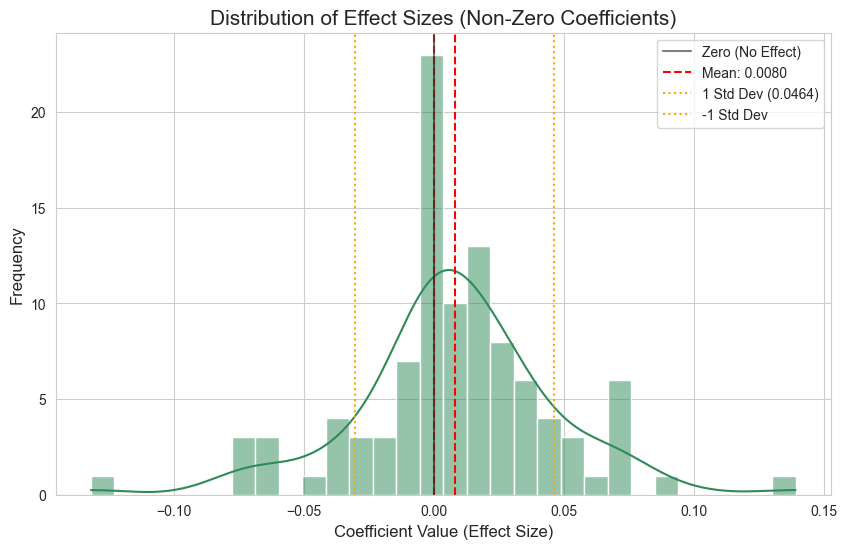

Mean Effect Size: 0.008038
Standard Deviation: 0.038394


In [121]:
# 1. Extract coefficients and pair them with feature names
coef_df = pd.DataFrame({
    'Gene': X.columns,
    'EffectSize': model.coef_
})

# 2. Filter for "significant" (non-zero) features
# (Elastic nets do not provide p-values instead we rely on the effect sizes.)
significant_features = coef_df[coef_df['EffectSize'] != 0]
effects = significant_features['EffectSize']
mu = effects.mean()
sigma = effects.std()

print(f"Total features started with: {len(coef_df)}")
print(f"Significant features (non-zero): {len(significant_features)}")

# 3. Create the Distribution Plot
plt.figure(figsize=(10, 6))
sns.histplot(significant_features['EffectSize'], kde=True, color="seagreen", bins=30)

# Add a vertical line at 0 for reference
plt.axvline(0, color='red', linestyle='--', alpha=0.6)

plt.title('Distribution of Effect Sizes (Non-Zero Coefficients)', fontsize=15)
plt.xlabel('Coefficient Value (Effect Size)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add vertical lines
plt.axvline(0, color='black', linestyle='-', label='Zero (No Effect)', alpha=0.5)
plt.axvline(mu, color='red', linestyle='--', label=f'Mean: {mu:.4f}')
plt.axvline(mu + 1*sigma, color='orange', linestyle=':', label=f'1 Std Dev ({mu+sigma:.4f})')
plt.axvline(mu - 1*sigma, color='orange', linestyle=':', label='-1 Std Dev')

plt.legend()

plt.show()
#########

print(f"Mean Effect Size: {mu:.6f}")
print(f"Standard Deviation: {sigma:.6f}")

- The positive mean effect size tells us that, on average, the genes identified by the model have a small, positive contribution.

- The Standard Deviation (≈0.038) is significantly larger than the mean. This implies that while many genes have a tiny effect, there is a long tail of high-impact genes.

We use the mean and standard deviation calculated above to filter for genes with unusually large effect sizes.

In [122]:
# Extract the hits using the calculated thresholds
# We use a 3 sigma threshold
# With a 3-sigma threshold we are defining "significant" biomarkers as those 
# that sit in the extreme 0.3% of your coefficient distribution. 
# 
# We use a very conservative filter here to obtain robust results 
# due to the high dimensionality and noise in the data.
upper_threshold = mu + 3 * sigma
lower_threshold = mu - 3 * sigma

hits = significant_features[
    (significant_features['EffectSize'] > upper_threshold) | 
    (significant_features['EffectSize'] < lower_threshold)
]

print(f"Number of high-confidence hits: {len(hits)}")
print(hits.sort_values(by='EffectSize', ascending=False))

Number of high-confidence hits: 2
                  Gene  EffectSize
12326  STK32A (202374)    0.139128
8049     MIEN1 (84299)   -0.131751


1) A negative coefficient means that as the gene's expression increases, the LN_IC50 decreases. I.e. for genes with negative coeffcients, more gene expression is correlated with increased sensitivity to the drug.
2) Positive Coefficient: High gene expression → High LN_IC50 → Decreased Sensitivity (Resistance).

In a nutshell: A gene with a strongly negative coefficient, should be interpreted as a "Sensitivity Driver." Knocking out that gene or reducing its expression, could (could because correlation is not causation) lead to a more resistant cell (because the IC50 would go up).

Since we use an elastic net model the hits above actually might represent clusters of highly correlated genes. Therefore, we should also look at the genes
correlated to these hit.

Remark: The number behind the gene refers to the Entrez ID

1. MIEN1:

    In the human genome, MIEN1 and PGAP3 are "neighbors" in the truest sense. They are both located on chromosome 17q12, right in the same neighborhood as ERBB2 (HER2).

    They are almost always co-amplified in cancer (especially breast and gastric cancers).

2. STK32A:

    STK32A seems to be an independent predictor.

In [123]:
# We can also have a look at the lower confidence hits
# by applying a 2 sigma rule
upper_threshold = mu + 2 * sigma
lower_threshold = mu - 2 * sigma

hits = significant_features[
    (significant_features['EffectSize'] > upper_threshold) | 
    (significant_features['EffectSize'] < lower_threshold)
]

print(f"Number of high-confidence hits: {len(hits)}")
print(hits.sort_values(by='EffectSize', ascending=False))

Number of high-confidence hits: 6
                  Gene  EffectSize
12326  STK32A (202374)    0.139128
13449  DNAH12 (201625)    0.093824
15548     KRT16 (3868)   -0.069999
6091        ART1 (417)   -0.074055
1593   SLC27A5 (10998)   -0.077515
8049     MIEN1 (84299)   -0.131751


## Comparison of models

Now let us compare the two models and see if we find anything interesting.

In [124]:
# 2. Get significant components from ANCOVA
sig_pcs = ['PC2', 'PC7', 'PC3', 'PC11']
significant_features_reindexed = significant_features.set_index("Gene")

# 3. Create a summary DataFrame
comparison_data = []

for gene in significant_features_reindexed.index:
    if gene in df_loadings.index:
        # Extract the loading for this gene in the significant PCs
        row_loadings = df_loadings.loc[gene, sig_pcs]
        
        # Add to comparison data
        comparison_data.append({
            'Gene': gene,
            'ElasticNet_Coef': significant_features_reindexed.loc[gene, "EffectSize"],
            **row_loadings.to_dict()
        })

df_overlap = pd.DataFrame(comparison_data)

print(df_overlap.head(10))

              Gene  ElasticNet_Coef       PC2       PC7       PC3      PC11
0     GGCT (79017)        -0.041872  0.001174 -0.005078  0.015981  0.005936
1  ST3GAL6 (10402)         0.008629  0.001292  0.013711 -0.010691  0.014536
2    TGFBR3 (7049)         0.009639  0.009118  0.007954  0.000897  0.008894
3  SLC27A5 (10998)        -0.077515 -0.011078  0.001419  0.005632 -0.001814
4    AAMDC (28971)         0.036635  0.010653 -0.000993 -0.005259 -0.017788
5      ELOB (6923)         0.003254  0.004346  0.006352 -0.001426 -0.013887
6      FGL1 (2267)         0.003836  0.002487  0.009703  0.004812 -0.001096
7   CHCHD2 (51142)        -0.000842  0.000764  0.002845 -0.000981 -0.010240
8    USP42 (84132)        -0.003129  0.001958 -0.004591  0.008453  0.005394
9   ZNHIT1 (10467)         0.013287  0.007028  0.015268 -0.005476 -0.010044


Let us look at the two genes with very large effect sizes in the elast net model:

In [125]:
log = ['STK32A (202374)', 'MIEN1 (84299)']
filt = df_overlap["Gene"].isin(log)
df_overlap[filt]

,Gene,ElasticNet_Coef,PC2,PC7,PC3,PC11
34,MIEN1 (84299),-0.131751,0.002881,0.004642,0.008034,-0.007932
62,STK32A (202374),0.139128,0.006432,0.015205,-0.000385,-0.000979


- MIEN1 has a very low loading in all 4 PCA components.
- STK32A has a relatively large positive loading in PC7 + its regression coefficient in the PCR model was positive.
  
Both models agree that higher levels of STK32A are associated with an increase in  LN_IC50. 

We will look where it falls in the distribution to get a feeling how relevant this is.

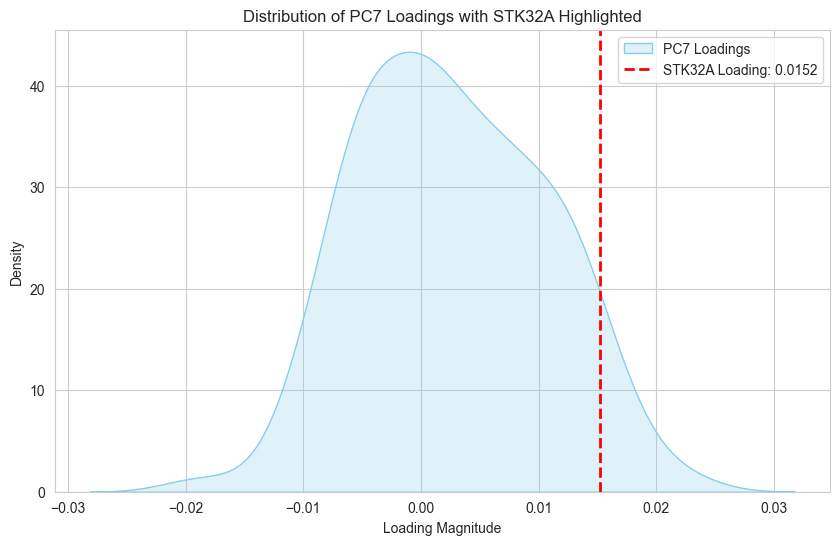

In [126]:
# 1. Plot the distribution of all loadings for PC2
plt.figure(figsize=(10, 6))
sns.kdeplot(df_overlap['PC7'], fill=True, color='skyblue', label='PC7 Loadings')

# 2. Get the specific loading for MIEN1
mien1_loading = df_overlap[df_overlap['Gene'].str.contains('STK32A')]['PC7'].values[0]

# 3. Add a vertical line for MIEN1
plt.axvline(mien1_loading, color='red', linestyle='--', linewidth=2, 
            label=f'STK32A Loading: {mien1_loading:.4f}')

# 4. Annotate the plot
plt.title('Distribution of PC7 Loadings with STK32A Highlighted')
plt.xlabel('Loading Magnitude')
plt.ylabel('Density')
plt.legend()
plt.show()

# Summary

A biologist might find the following links interesting and could confirm or disconfirm thse conclusions.

STK32A: 
    - There is not much evidence in literature that STK32A and lepatinib is linked. However, we need to have in mind that the elastic net model picks relatively arbitrarily a feature among many correlated features. Therefore, we also need to look at the "neighborhood" of genes of STK32A.

MIEN1:
    - MIEN1 is located on the 17q12 locus, right next to ERBB2 (HER2). They are almost always co-amplified. In Lapatinib studies, MIEN1 is often found to be upregulated in resistant cells because it helps "bypass" the inhibited HER2 by activating the Akt/NF-κB pathway independently. Lapatinib is generally used for advanced or metastatic (Stage IV) breast cancer that is HER2-positive.
    
    Supporting Paper: K Evans et al., "MIEN1 drives breast tumor cell migration by regulating cytoskeletal-focal adhesion dynamics," PMC5342390.

    "Emerging targets in cancer drug resistance" (published in Cancer Drug Resistance)


It also might be worth looking at the "2sigma-hits" of the ellastic net model:

    - DNAH12 (positive effectsize)
    - KRT16 (negative effectsize)
    - ART1 (negative effectsize)
    - SLC27A5 (negative effectsize)